# RecoMart — Data Preparation & EDA (Task 5)

This notebook demonstrates the **data cleaning / preprocessing** and **exploratory data analysis** performed on the RecoMart interaction data. It reuses the production pipeline code in `src/` so the notebook and the automated pipeline stay consistent.

**Contents**
1. Setup
2. Pipeline layers (Bronze -> Silver -> Gold) and cleaning logic
3. Data quality validation report
4. Descriptive profiling (size, interaction totals, sparsity)
5. Interaction distributions, popularity, and co-occurrence plots

## 1. Setup

Add the repository root to the path and point at the SQLite database produced by the ingestion + curation pipeline.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.core import connect, table_counts
from src.validation import validate
from src.modeling import profile_gold, generate_eda_plots

DB_PATH = ROOT / "data" / "recomart.db"
assert DB_PATH.exists(), (
    f"{DB_PATH} not found. Build it first, e.g. `python -m src.recomart run`."
)
DB_PATH

WindowsPath('C:/Users/neave/Documents/GitHub/recomart-recommender/data/recomart.db')

## 2. Pipeline layers and cleaning logic

The medallion layers apply the cleaning and preprocessing steps:

- **Bronze** — raw ingested events, item properties, and category tree.
- **Silver** — cleaned data: invalid event types and negative/zero IDs and timestamps are filtered out, timestamps are normalised to ISO format, and only the *latest* value per item property is retained (deduplication).
- **Gold** — model-ready features: user-item interactions are aggregated into weighted interaction scores (view=1, addtocart=3, transaction=5) and categorical item properties are encoded into sparse hashed feature vectors.

The row counts below show the effect of each layer.

In [2]:
db = connect(DB_PATH)
try:
    counts = table_counts(db)
finally:
    db.close()

for name, count in counts.items():
    print(f"{name:<32} {count:>12,}")

bronze_category_tree                    1,669
bronze_events                       2,756,101
bronze_item_properties             20,275,902
feature_item_cooccurrence             357,790
feature_item_cooccurrence_versions      357,790
feature_item_pair_stats             1,904,167
feature_item_popularity               417,053
feature_item_popularity_versions      417,053
feature_registry                            3
feature_user_activity               1,407,580
feature_user_activity_versions      1,407,580
gold_item_features                    417,053
gold_user_item_features             2,145,179
silver_category_hierarchy               1,669
silver_products                       417,053
silver_user_events                  2,756,101


## 3. Data quality validation report

`validate()` runs automated checks: valid event types only, product/user-item uniqueness (no duplicates), the interaction-score formula, and vector completeness.

In [3]:
report = validate(DB_PATH)
print(json.dumps(report, indent=2))
assert report["ok"], "Data quality checks failed"

{
  "counts": {
    "bronze_category_tree": 1669,
    "bronze_events": 2756101,
    "bronze_item_properties": 20275902,
    "feature_item_cooccurrence": 357790,
    "feature_item_cooccurrence_versions": 357790,
    "feature_item_pair_stats": 1904167,
    "feature_item_popularity": 417053,
    "feature_item_popularity_versions": 417053,
    "feature_registry": 3,
    "feature_user_activity": 1407580,
    "feature_user_activity_versions": 1407580,
    "gold_item_features": 417053,
    "gold_user_item_features": 2145179,
    "silver_category_hierarchy": 1669,
    "silver_products": 417053,
    "silver_user_events": 2756101
  },
  "checks": {
    "valid_event_types": true,
    "unique_products": true,
    "unique_user_items": true,
    "scores_match": true,
    "vectors_present": true,
    "feature_users_complete": true,
    "feature_items_complete": true,
    "feature_scores_present": true,
    "feature_cooccurrence_ranked": true
  },
  "ok": true
}


## 4. Descriptive profiling

`profile_gold()` summarises dataset size, interaction totals, sparsity, and the per-user / per-item interaction distributions.

In [4]:
profile = profile_gold(DB_PATH, top_n=15)

print("Size")
for key, value in profile["size"].items():
    print(f"  {key:<20} {value:>12,}")

print("\nInteraction totals")
for key, value in profile["interaction_totals"].items():
    print(f"  {key:<20} {value:>12,}")

print("\nSparsity")
for key, value in profile["sparsity"].items():
    print(f"  {key:<28} {value:,.6f}" if isinstance(value, float) else f"  {key:<28} {value:,}")

Size
  users                   1,407,580
  interacted_items          235,061
  catalog_items             417,053
  user_item_pairs         2,145,179

Interaction totals
  views                   2,664,312
  add_to_carts               69,332
  purchases                  22,457
  weighted_score          2,984,593

Sparsity
  possible_user_item_pairs     330,867,162,380
  observed_density             0.000006
  sparsity                     0.999994


In [5]:
print("Items per user (interaction count percentiles)")
for key, value in profile["items_per_user"].items():
    print(f"  {key:<6} {value:,.2f}" if isinstance(value, float) else f"  {key:<6} {value:,}")

print("\nUsers per item (interaction count percentiles)")
for key, value in profile["users_per_item"].items():
    print(f"  {key:<6} {value:,.2f}" if isinstance(value, float) else f"  {key:<6} {value:,}")

Items per user (interaction count percentiles)
  min    1
  mean   1.52
  p50    1
  p90    2
  p99    8
  max    3,814

Users per item (interaction count percentiles)
  min    1
  mean   9.13
  p50    2
  p90    20
  p99    105
  max    2,912


## 5. Summary plots (histograms & heatmap)

`generate_eda_plots()` renders the summary plots to `reports/eda/` and returns their paths. We display them inline below.

In [6]:
plots = generate_eda_plots(DB_PATH, out_dir=ROOT / "reports" / "eda", top_n=15)
print(json.dumps(plots, indent=2))

{
  "output_dir": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda",
  "plots": {
    "interaction_totals": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda\\interaction_totals.png",
    "items_per_user": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda\\items_per_user_hist.png",
    "users_per_item": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda\\users_per_item_hist.png",
    "top_items": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda\\top_items.png",
    "top_categories": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda\\top_categories.png",
    "item_cooccurrence_heatmap": "C:\\Users\\neave\\Documents\\GitHub\\recomart-recommender\\reports\\eda\\item_cooccurrence_heatmap.png"
  }
}


interaction_totals


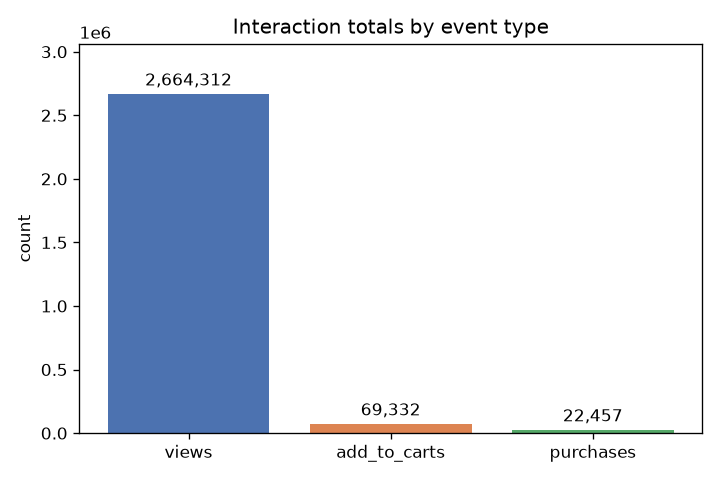

items_per_user


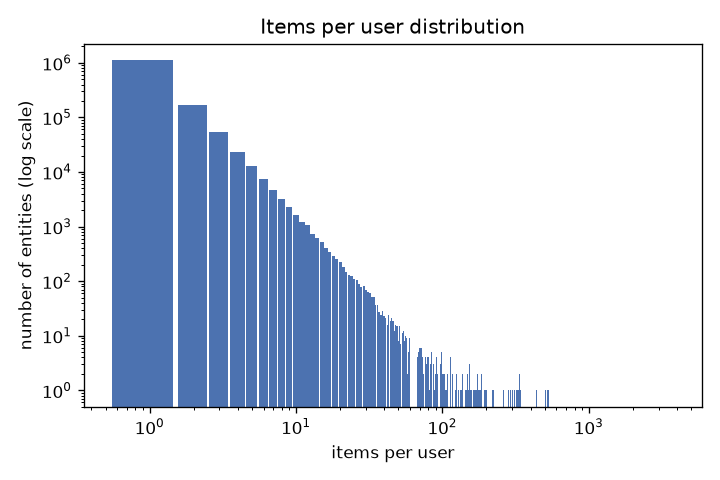

users_per_item


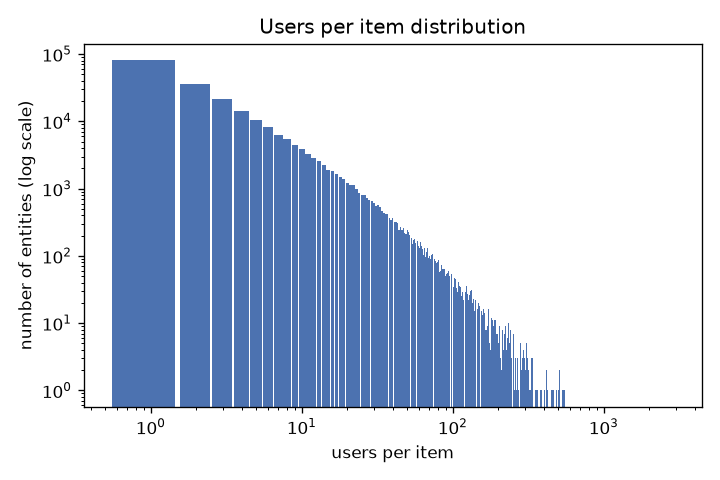

top_items


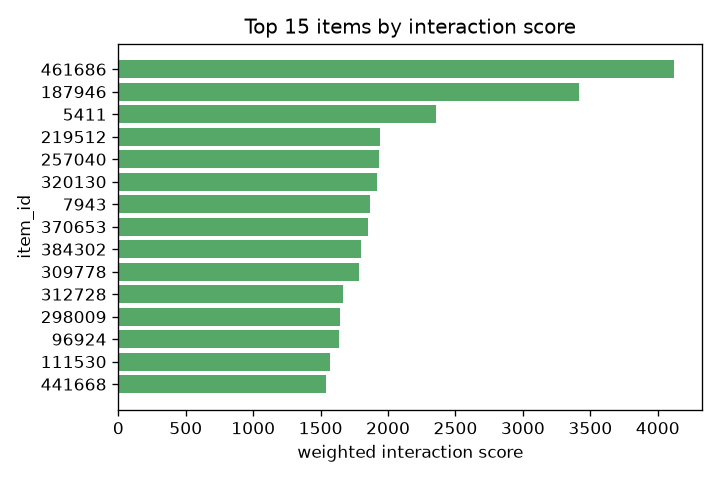

top_categories


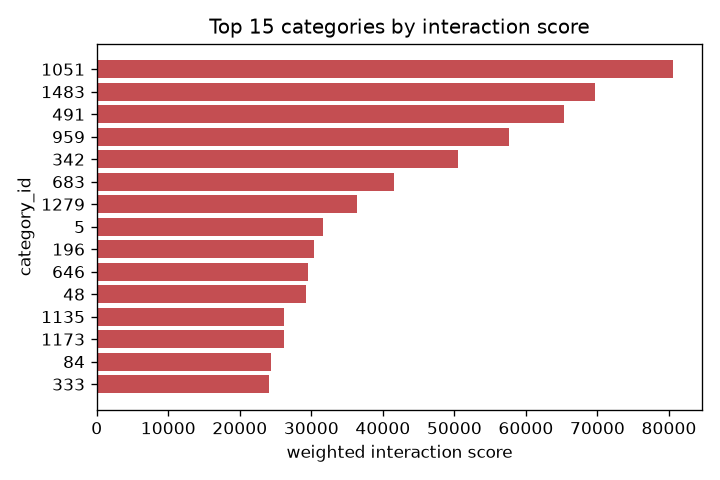

item_cooccurrence_heatmap


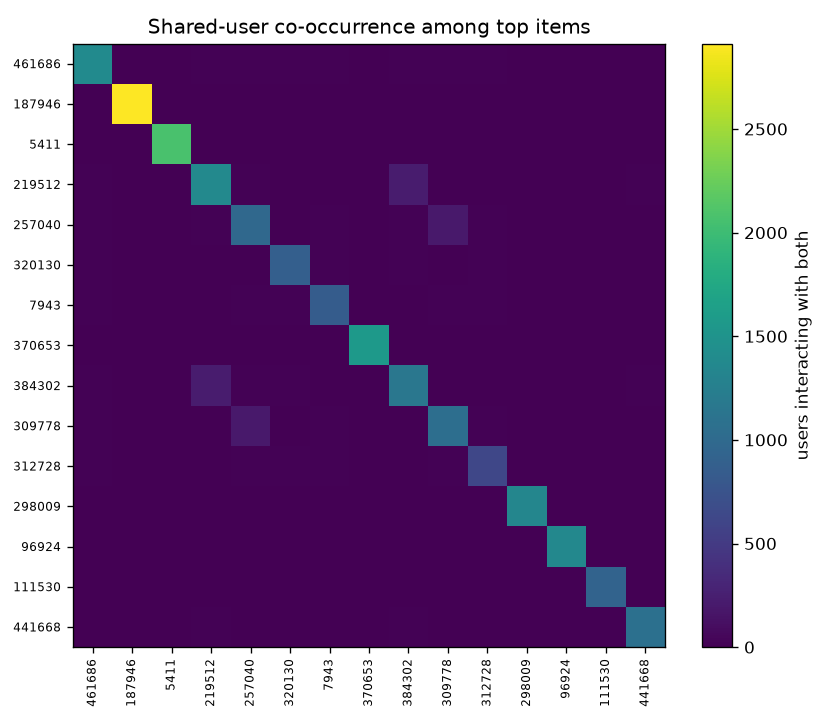

In [7]:
from IPython.display import Image, display

for name, path in plots["plots"].items():
    print(name)
    display(Image(filename=path))